In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')

genre_names = ['blues', 'classical', 'country', 'disco', 'hiphop', 
               'jazz', 'metal', 'pop', 'reggae', 'rock']

In [2]:
test  = pd.read_csv('../data/processed/test.csv')
X_test = test.drop(columns=['label'])
y_test = test['label']

models = {
    'KNN':                 joblib.load('../outputs/models/knn.pkl'),
    'Logistic Regression': joblib.load('../outputs/models/logistic_regression.pkl'),
    'SVM':                 joblib.load('../outputs/models/svm.pkl'),
    'Random Forest':       joblib.load('../outputs/models/random_forest.pkl')
}

In [3]:
print("Final Test Accuracies:")
print("-" * 35)

test_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_results[name] = y_pred
    print(f"{name:25s} | {acc:.3f}")

Final Test Accuracies:
-----------------------------------
KNN                       | 0.673
Logistic Regression       | 0.733
SVM                       | 0.713
Random Forest             | 0.740


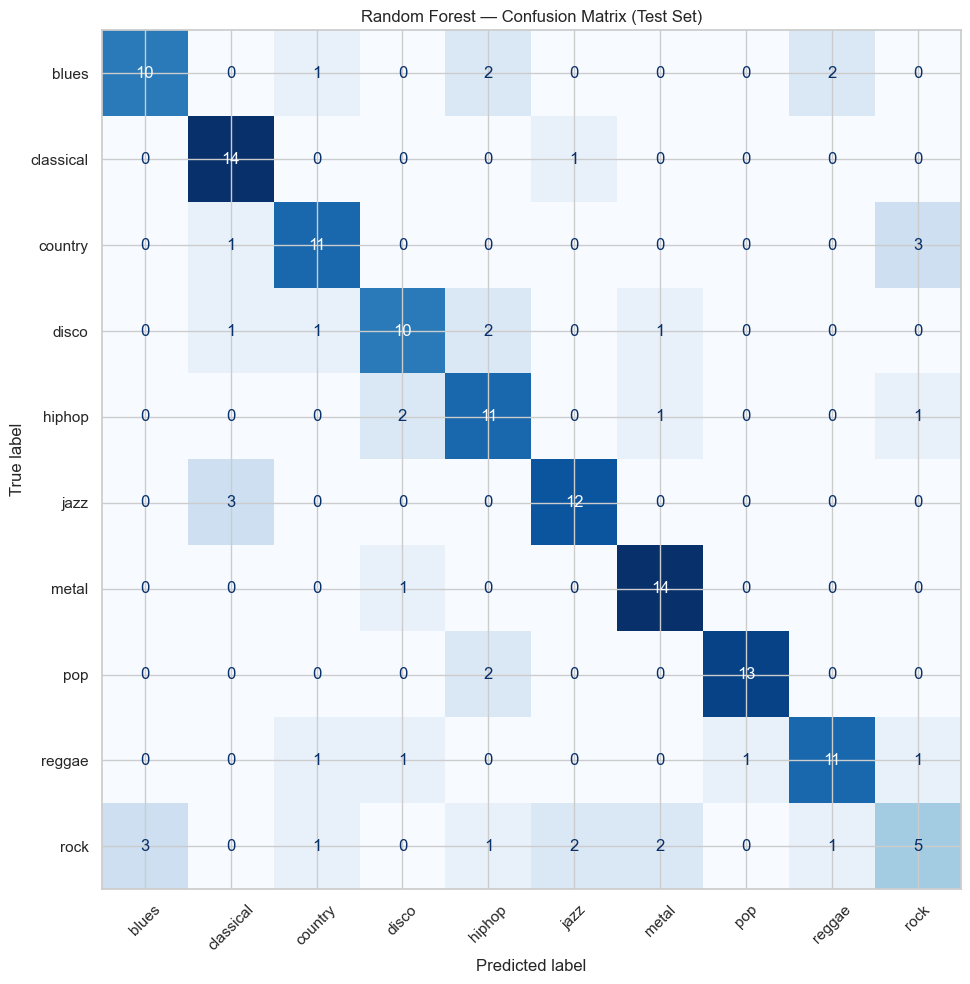

In [4]:
# Use Random Forest as it had highest val accuracy
y_pred_rf = test_results['Random Forest']

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix (Test Set)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_rf.png')
plt.show()

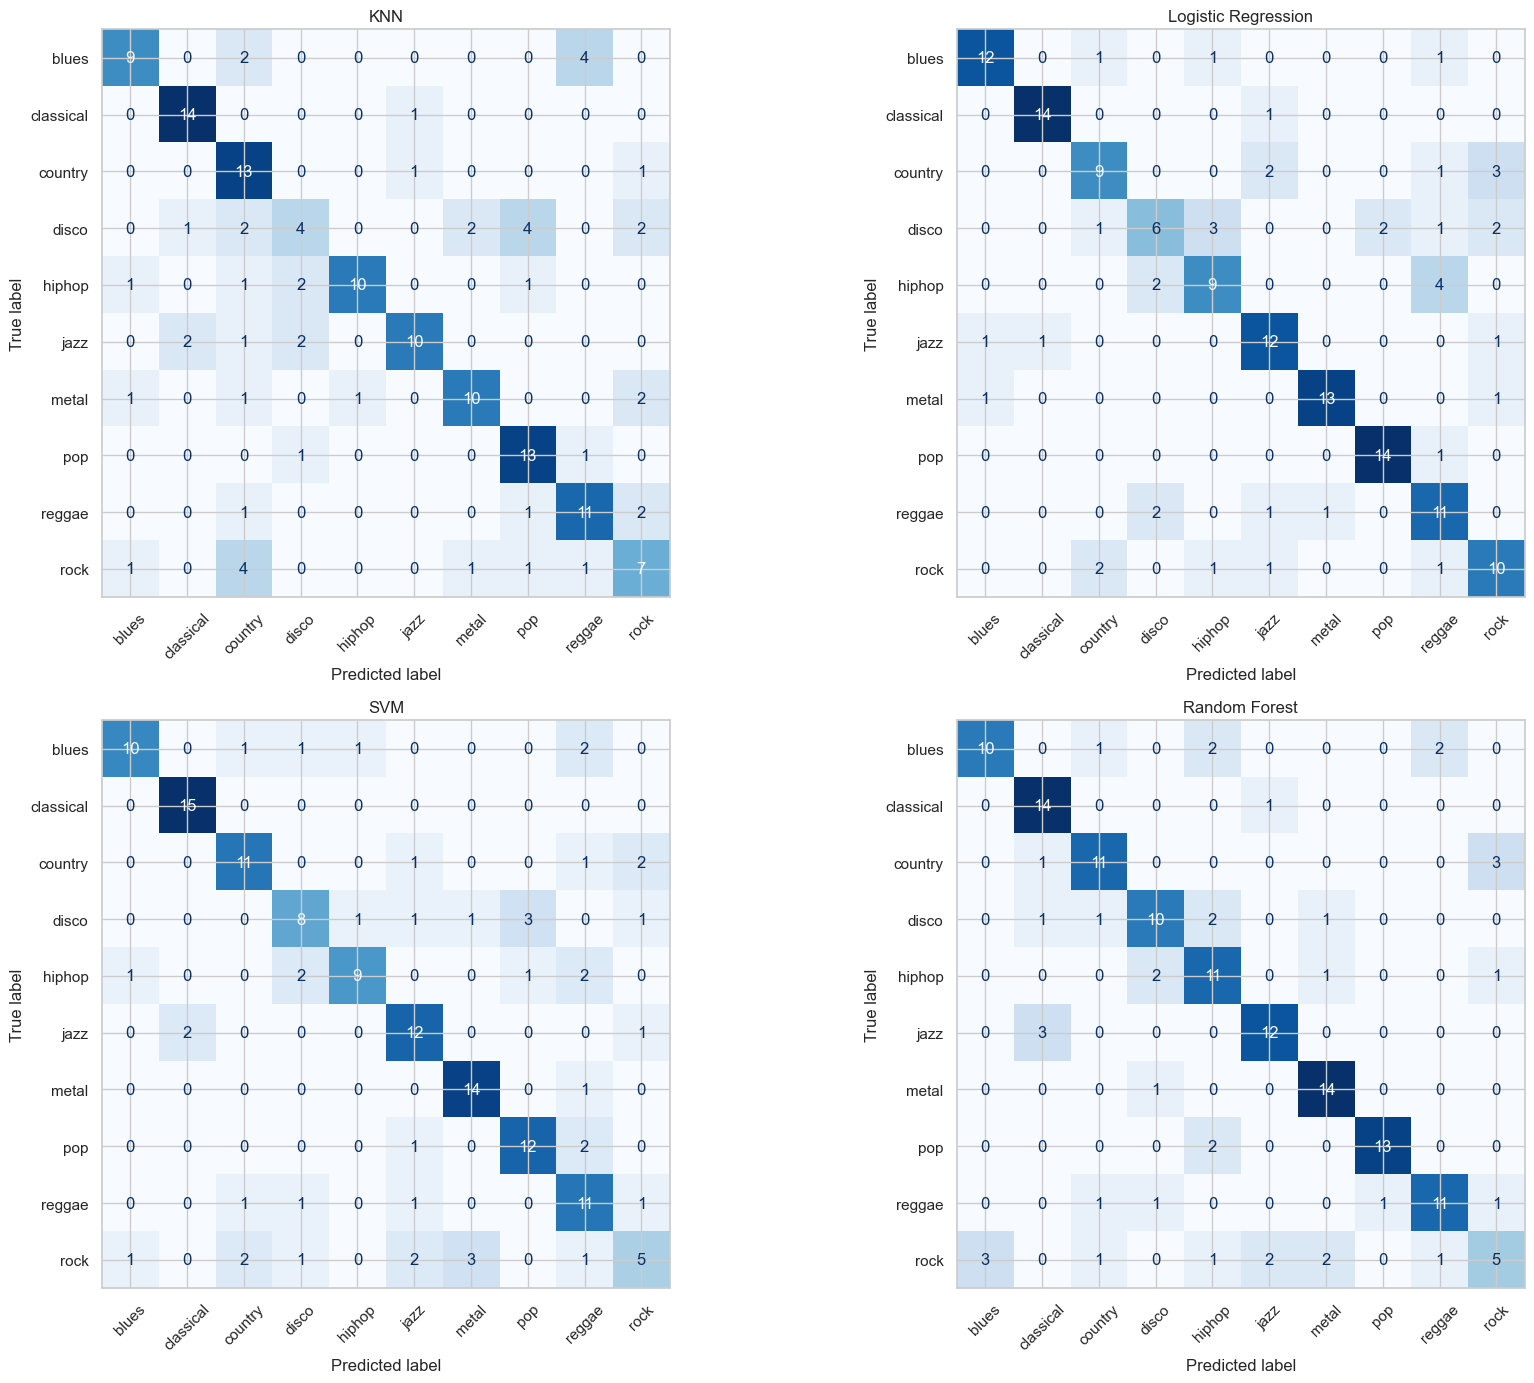

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, (name, y_pred) in zip(axes.flatten(), test_results.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
    ax.set_xticklabels(genre_names, rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices_all.png')
plt.show()

In [6]:
print("Random Forest — Per Genre Report:\n")
print(classification_report(y_test, test_results['Random Forest'], 
                             target_names=genre_names))

Random Forest — Per Genre Report:

              precision    recall  f1-score   support

       blues       0.77      0.67      0.71        15
   classical       0.74      0.93      0.82        15
     country       0.73      0.73      0.73        15
       disco       0.71      0.67      0.69        15
      hiphop       0.61      0.73      0.67        15
        jazz       0.80      0.80      0.80        15
       metal       0.78      0.93      0.85        15
         pop       0.93      0.87      0.90        15
      reggae       0.79      0.73      0.76        15
        rock       0.50      0.33      0.40        15

    accuracy                           0.74       150
   macro avg       0.74      0.74      0.73       150
weighted avg       0.74      0.74      0.73       150



## Summary

- Random Forest achieved the highest test accuracy
- Classical and metal are typically the easiest genres to classify 
  (very distinct sonic characteristics)
- Rock/country and disco/pop are commonly confused pairs 
  (overlapping features)
- These confusion patterns will be explored further in notebook 5